<h1> 2C QUANTITATIVE ANALYSIS OF SURVEY RESULTS</h1>

In [1]:
# Run if needed (if next cell fails)
!pip install openpyxl

# Improt Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


<h3>DATA CLEANING</h3>

In [2]:
# Get data from spreadsheet
df = pd.read_excel('survey_data.xlsx')

# Remove irrelevant and empty columns, remove ID 14 for unusable repsonse
trimmed_df = df.drop(columns=["Start time", "Completion time", "Email", "Name", "Last modified time"]).drop(index=[13]).reset_index(drop=True)
# Identify BREQ3 statement columns
breq = trimmed_df.columns[2:25]  # adjust indices if needed
# Strip whitespace from BREQ columns by converting to string, and then convert values to int for later use
trimmed_df[breq] = trimmed_df[breq].apply(lambda x: pd.to_numeric(x.astype(str).str.strip(), errors='coerce'))

# Test
#print(trimmed_df[breq].dtypes)

In [3]:
# Assign numeric values to BREQ statements and rename all other columns
for i, ibreq in enumerate(range(2, 25)):
    trimmed_df.columns.values[ibreq] = f"{i+1}"
trimmed_df.columns.values[1] = "Age"
trimmed_df.columns.values[25] = "Sex"
trimmed_df.columns.values[26] = "Gender"
trimmed_df.columns.values[27] = "Activity"
trimmed_df.columns.values[28] = "Time"
trimmed_df.columns.values[29] = "Benefits"
trimmed_df.columns.values[30] = "Other"
# Ensure application of renaming
trimmed_df.columns = trimmed_df.columns.tolist()

# Test
#trimmed_df.columns
trimmed_df.head()

,ID,Age,1,2,3,4,5,6,7,8,...,20,21,22,23,Sex,Gender,Activity,Time,Benefits,Other
0,1,27,1,3,0,1,2,3,0,1,...,1,0,0,0,Female,Female,I do other forms of moderate-intense exercise ...,NaN,NaN,NaN
1,2,21,0,1,0,0,0,0,0,1,...,1,0,0,0,Male,Male,I am not currently moderately-intensely physic...,NaN,NaN,Physical disability
2,3,23,3,0,1,2,4,0,2,3,...,2,2,2,2,Female,Female,I do other forms of moderate-intense exercise ...,NaN,NaN,NaN
3,4,22,1,3,0,2,1,3,0,1,...,0,1,2,1,Female,Female,I do other forms of moderate-intense exercise ...,NaN,NaN,I feel as though I wouldn’t know where to star...
4,5,21,2,1,2,2,3,2,1,2,...,3,3,4,3,Female,Female,I do other forms of moderate-intense exercise ...,NaN,NaN,Is climbing not a form of rt??


<h3>FILTER & SPLIT</h3>

In [4]:
# Filter for jsut female responses
trimmed_df = trimmed_df[trimmed_df['Sex'] == 'Female']

In [5]:
# Assign demographic group based on activity level/type
def assign_group(activity):
    if "I currently do RT regularly recreationally" in activity:
        return "RT"
    elif "I play a sport that involves resistance" in activity:
        return "RT"
    elif "I do other forms of moderate-intense exercise" in activity:
        return "Other Exercise"
    else:
        return "Inactive"

trimmed_df["Group"] = trimmed_df["Activity"].apply(assign_group)

# Test
print(trimmed_df["Group"].value_counts())

Group
RT                13
Other Exercise    10
Inactive           8
Name: count, dtype: int64


<h3>MEAN SCORES ANALYSIS</h3>

In [6]:
# Assign each statement number to its relevant subscale (motivational profile/regulation type)
subscales = {
    "Amotivation": ["2", "6", "10", "14"],
    "External": ["4", "8", "12", "16"],
    "Introjected": ["3", "7", "11", "15"],
    "Identified": ["1", "5", "9", "13"],
    "Integrated": ["17", "18", "22"],
    "Intrinsic": ["19", "21", "22", "23"]
}

# Calculate each respondant's mean score for each subscale and add to df
for subscale, items in subscales.items():
    trimmed_df[subscale] = round(trimmed_df[items].mean(axis=1), 2)
    
trimmed_df.head()

,ID,Age,1,2,3,4,5,6,7,8,...,Time,Benefits,Other,Group,Amotivation,External,Introjected,Identified,Integrated,Intrinsic
0,1,27,1,3,0,1,2,3,0,1,...,NaN,NaN,NaN,Other Exercise,2.50,0.50,0.00,1.00,0.33,0.00
2,3,23,3,0,1,2,4,0,2,3,...,NaN,NaN,NaN,Other Exercise,0.00,1.25,0.75,2.75,1.33,2.25
3,4,22,1,3,0,2,1,3,0,1,...,NaN,NaN,I feel as though I wouldn’t know where to star...,Other Exercise,2.50,0.75,0.00,0.75,1.00,1.25
4,5,21,2,1,2,2,3,2,1,2,...,NaN,NaN,Is climbing not a form of rt??,Other Exercise,0.75,1.50,2.25,2.75,3.33,3.25
5,6,27,3,2,3,3,3,2,3,2,...,1-2 years.,Clear mind,NaN,RT,2.00,2.00,2.50,3.00,2.67,3.00


In [7]:
# Calculate group subscale means 
group_means = round(trimmed_df.groupby("Group")[list(subscales)].mean(), 2)
group_means

,Amotivation,External,Introjected,Identified,Integrated,Intrinsic
Group,,,,,,
Inactive,1.41,1.06,1.25,1.75,1.46,2.12
Other Exercise,1.18,1.05,0.88,1.75,1.60,2.08
RT,0.29,1.12,2.25,3.04,2.46,2.69


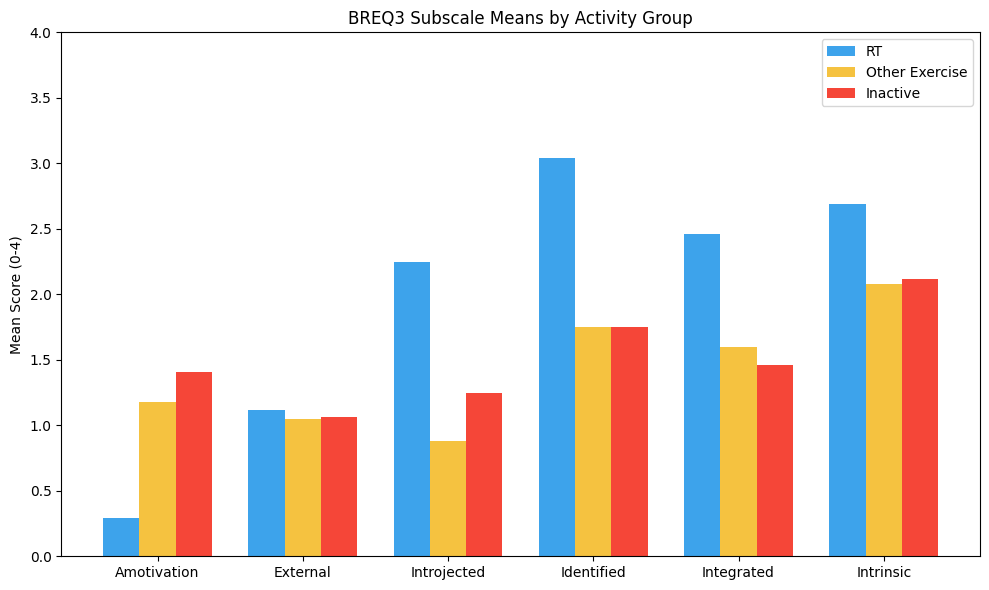

In [8]:
# Plot group means
x = np.arange(len(subscales))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

RT_bar = ax.bar(x - width, group_means.loc["RT"], width, label="RT", color="#3DA3EB")
other_bar = ax.bar(x, group_means.loc["Other Exercise"], width, label="Other Exercise", color="#F5C240")
inactive_bar = ax.bar(x + width, group_means.loc["Inactive"], width, label="Inactive", color="#F54638")

ax.set_xticks(x)
ax.set_xticklabels(subscales)
ax.set_ylabel("Mean Score (0-4)")
ax.set_title("BREQ3 Subscale Means by Activity Group")
ax.legend()
ax.set_ylim(0, 4)

plt.tight_layout()
plt.show()

<h3>RELATIVE AUTONOMY INDEX ANALYSIS</h3>

In [9]:
# Calculate RAI for each respondant
trimmed_df["RAI"] = (
(trimmed_df["Amotivation"] * -3) + 
(trimmed_df["External"] * -2) + 
(trimmed_df["Introjected"] * -1) + 
(trimmed_df["Identified"] * 1) +
(trimmed_df["Integrated"] * 2) +
(trimmed_df["Intrinsic"] * 3)
)

trimmed_df.head()

,ID,Age,1,2,3,4,5,6,7,8,...,Benefits,Other,Group,Amotivation,External,Introjected,Identified,Integrated,Intrinsic,RAI
0,1,27,1,3,0,1,2,3,0,1,...,NaN,NaN,Other Exercise,2.50,0.50,0.00,1.00,0.33,0.00,-6.84
2,3,23,3,0,1,2,4,0,2,3,...,NaN,NaN,Other Exercise,0.00,1.25,0.75,2.75,1.33,2.25,8.91
3,4,22,1,3,0,2,1,3,0,1,...,NaN,I feel as though I wouldn’t know where to star...,Other Exercise,2.50,0.75,0.00,0.75,1.00,1.25,-2.50
4,5,21,2,1,2,2,3,2,1,2,...,NaN,Is climbing not a form of rt??,Other Exercise,0.75,1.50,2.25,2.75,3.33,3.25,11.66
5,6,27,3,2,3,3,3,2,3,2,...,Clear mind,NaN,RT,2.00,2.00,2.50,3.00,2.67,3.00,4.84


In [10]:
# Calculate mean RAI by group
group_RAI = round(trimmed_df.groupby("Group")["RAI"].mean(), 2)
group_RAI

Group
Inactive           3.45
Other Exercise     4.68
RT                10.69
Name: RAI, dtype: float64

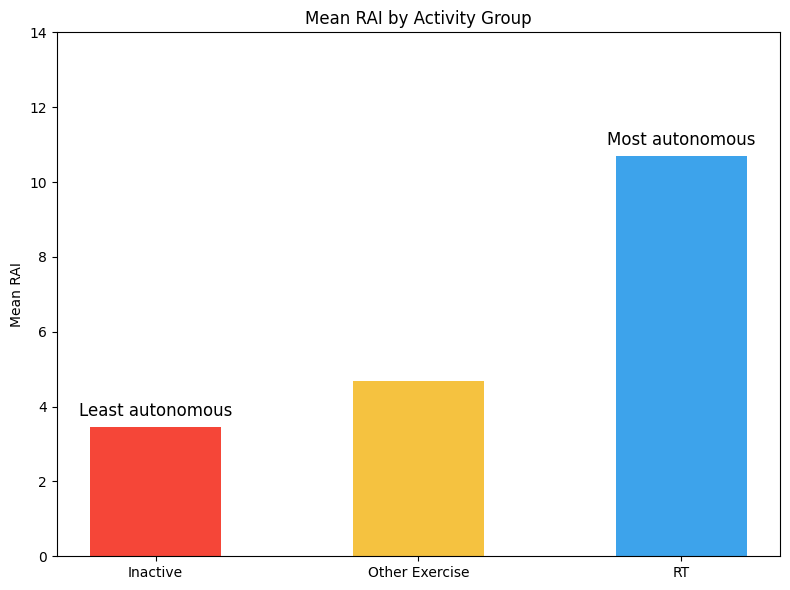

In [11]:
# Plot mean group RAI 
fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(group_RAI.index, group_RAI.values, color=["#F54638", "#F5C240", "#3DA3EB"], width=0.5)

ax.set_ylabel("Mean RAI")
ax.set_title("Mean RAI by Activity Group")
ax.set_ylim(0, 14)

for i, (group, value) in enumerate(group_RAI.items()):
    if group == "Inactive":
        ax.text(i, value + 0.2, "Least autonomous", ha="center", va="bottom", fontsize=12)
    if group == "RT":
        ax.text(i, value + 0.2, "Most autonomous", ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

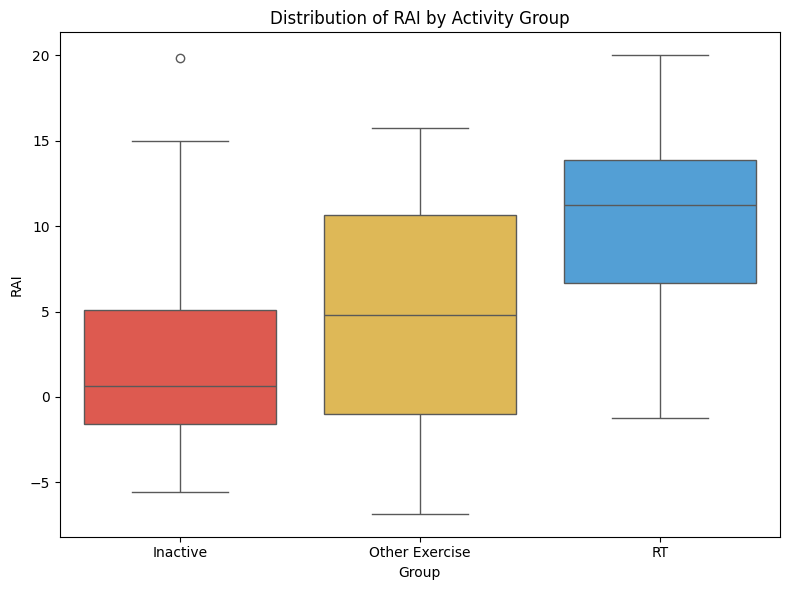

In [12]:
# Plot RAI distribution by group
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(data=trimmed_df, x="Group", y="RAI", hue="Group",
            palette={"Inactive": "#F54638", "Other Exercise": "#F5C240", "RT": "#3DA3EB"},
            order=["Inactive", "Other Exercise", "RT"], legend = False,
            ax=ax)

ax.set_ylabel("RAI")
ax.set_title("Distribution of RAI by Activity Group")

plt.tight_layout()
plt.show()

In [13]:
# Test to see if data is normally distributed
for group in ["Inactive", "Other Exercise", "RT"]:
    data = trimmed_df[trimmed_df["Group"] == group]["RAI"]
    stat, p = stats.shapiro(data)
    print(f"{group}: W={stat:.3f}, p={p:.3f}")

Inactive: W=0.833, p=0.064
Other Exercise: W=0.966, p=0.855
RT: W=0.966, p=0.838


In [14]:
# ANOVA test
anova = stats.f_oneway(
    trimmed_df[trimmed_df["Group"] == "Inactive"]["RAI"],
    trimmed_df[trimmed_df["Group"] == "Other Exercise"]["RAI"],
    trimmed_df[trimmed_df["Group"] == "RT"]["RAI"]
)
print(f"ANOVA: F={anova.statistic:.3f}, p={anova.pvalue:.3f}")

# Kruskal-Wallis test
kruskal = stats.kruskal(
    trimmed_df[trimmed_df["Group"] == "Inactive"]["RAI"],
    trimmed_df[trimmed_df["Group"] == "Other Exercise"]["RAI"],
    trimmed_df[trimmed_df["Group"] == "RT"]["RAI"]
)
print(f"Kruskal-Wallis: H={kruskal.statistic:.3f}, p={kruskal.pvalue:.3f}")


ANOVA: F=3.084, p=0.062
Kruskal-Wallis: H=5.046, p=0.080


In [19]:
groups = [trimmed_df[trimmed_df["Group"] == g]["RAI"].values 
          for g in ["Inactive", "Other Exercise", "RT"]]

f_stat, p_val = stats.f_oneway(*groups)

# Calculate eta squared
grand_mean = trimmed_df["RAI"].mean()
ss_between = sum(len(g) * (g.mean()-grand_mean)**2 for g in groups)
ss_total = sum(((trimmed_df["RAI"]-grand_mean)**2))
eta_squared = ss_between/ss_total

print(f"Eta squared: {eta_squared:.3f}")

# Epsilon squared for Kruskal-Wallis
h_stat, p_kruskal = stats.kruskal(*groups)
n = len(trimmed_df)
ep_squared = (h_stat-2)/(n-3)
print(f"Epsilon squared: {ep_squared:.3f}")



Eta squared: 0.181
Epsilon squared: 0.109
